In [2]:
import pandas as pd

df = pd.read_csv("shopping_trends.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)
print(df.head())

Dataset loaded successfully!
Shape: (3900, 19)
   Customer ID  Age Gender Item Purchased  Category  Purchase Amount (USD)  \
0            1   55   Male         Blouse  Clothing                     53   
1            2   19   Male        Sweater  Clothing                     64   
2            3   50   Male          Jeans  Clothing                     73   
3            4   21   Male        Sandals  Footwear                     90   
4            5   45   Male         Blouse  Clothing                     49   

        Location Size      Color  Season  Review Rating Subscription Status  \
0       Kentucky    L       Gray  Winter            3.1                 Yes   
1          Maine    L     Maroon  Winter            3.1                 Yes   
2  Massachusetts    S     Maroon  Spring            3.1                 Yes   
3   Rhode Island    M     Maroon  Spring            3.5                 Yes   
4         Oregon    M  Turquoise  Spring            2.7                 Yes   

  Payment

In [3]:
print("Columns:")
print(df.columns)

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

Columns:
Index(['Customer ID', 'Age', 'Gender', 'Item Purchased', 'Category',
       'Purchase Amount (USD)', 'Location', 'Size', 'Color', 'Season',
       'Review Rating', 'Subscription Status', 'Payment Method',
       'Shipping Type', 'Discount Applied', 'Promo Code Used',
       'Previous Purchases', 'Preferred Payment Method',
       'Frequency of Purchases'],
      dtype='object')

Data types:
Customer ID                   int64
Age                           int64
Gender                       object
Item Purchased               object
Category                     object
Purchase Amount (USD)         int64
Location                     object
Size                         object
Color                        object
Season                       object
Review Rating               float64
Subscription Status          object
Payment Method               object
Shipping Type                object
Discount Applied             object
Promo Code Used              object
Previous Purchases   

In [4]:
print(df.describe())

       Customer ID          Age  Purchase Amount (USD)  Review Rating  \
count  3900.000000  3900.000000            3900.000000    3900.000000   
mean   1950.500000    44.068462              59.764359       3.749949   
std    1125.977353    15.207589              23.685392       0.716223   
min       1.000000    18.000000              20.000000       2.500000   
25%     975.750000    31.000000              39.000000       3.100000   
50%    1950.500000    44.000000              60.000000       3.700000   
75%    2925.250000    57.000000              81.000000       4.400000   
max    3900.000000    70.000000             100.000000       5.000000   

       Previous Purchases  
count         3900.000000  
mean            25.351538  
std             14.447125  
min              1.000000  
25%             13.000000  
50%             25.000000  
75%             38.000000  
max             50.000000  


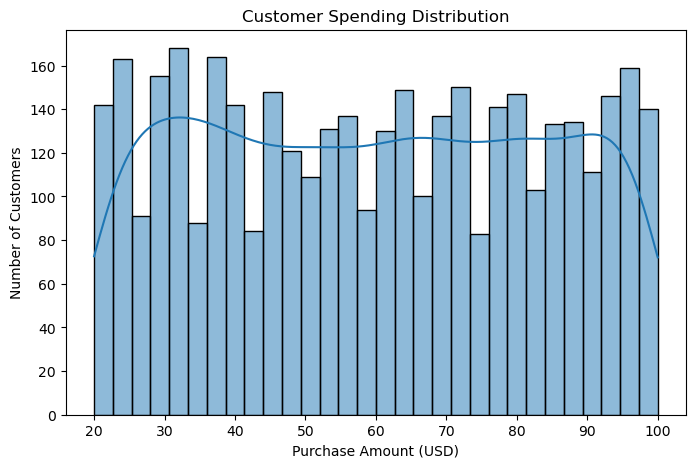

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Customer spending distribution
plt.figure(figsize=(8, 5))
sns.histplot(df["Purchase Amount (USD)"], bins=30, kde=True)
plt.title("Customer Spending Distribution")
plt.xlabel("Purchase Amount (USD)")
plt.ylabel("Number of Customers")
plt.show()

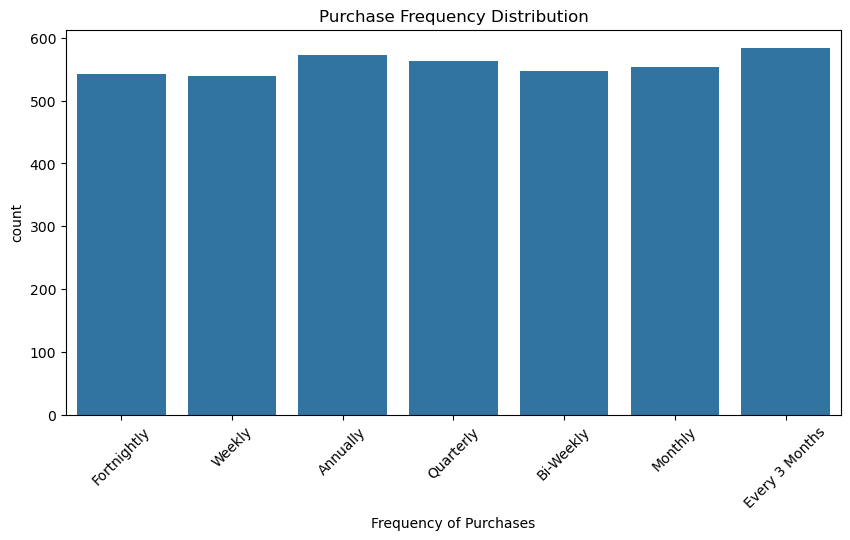

In [6]:
# Purchase frequency
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x="Frequency of Purchases"
)

plt.title("Purchase Frequency Distribution")
plt.xticks(rotation=45)
plt.show()

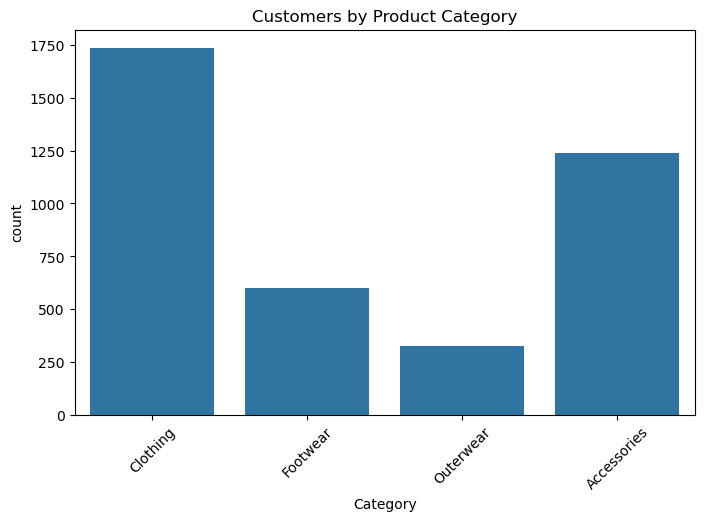

In [8]:
# Category analysis
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Category"
)

plt.title("Customers by Product Category")
plt.xticks(rotation=45)
plt.show()

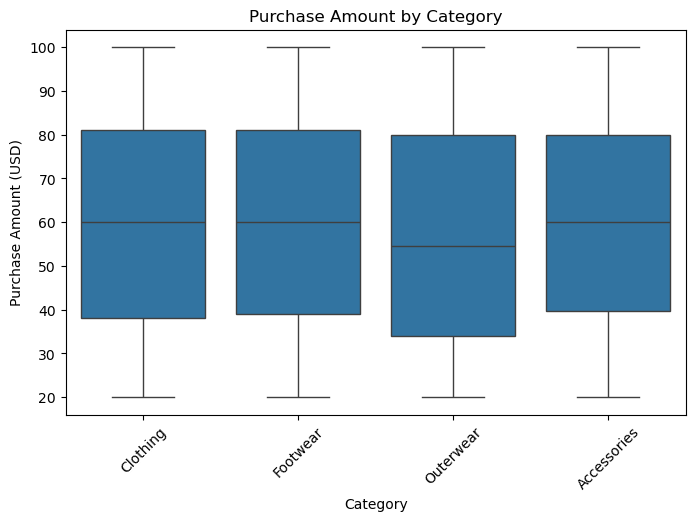

In [9]:
# Spending by category
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Category",
    y="Purchase Amount (USD)"
)

plt.title("Purchase Amount by Category")
plt.xticks(rotation=45)
plt.show()

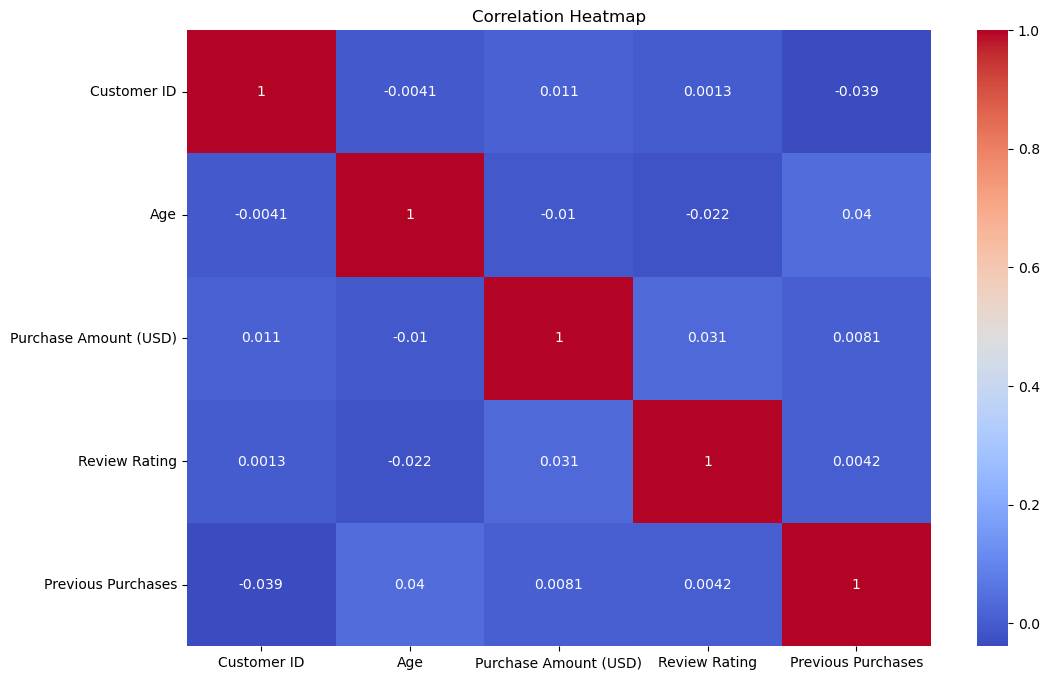

In [11]:
# Correlation heatmap
# First select the numerical columns:
numeric_df = df.select_dtypes(include="number")

plt.figure(figsize=(12, 8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

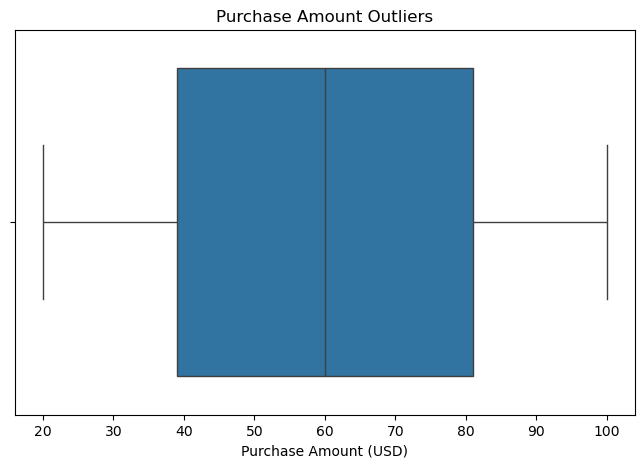

In [12]:
# Check outliers
plt.figure(figsize=(8, 5))

sns.boxplot(
    x=df["Purchase Amount (USD)"]
)

plt.title("Purchase Amount Outliers")
plt.show()

In [13]:
# Data Preprocessing.
# Remove Customer ID(Customer ID identifies the customer; it should not be used as a clustering feature.)



In [14]:
df_ml = df.drop(columns=["Customer ID"])

print("Customer ID removed")
print(df_ml.head())

Customer ID removed
   Age Gender Item Purchased  Category  Purchase Amount (USD)       Location  \
0   55   Male         Blouse  Clothing                     53       Kentucky   
1   19   Male        Sweater  Clothing                     64          Maine   
2   50   Male          Jeans  Clothing                     73  Massachusetts   
3   21   Male        Sandals  Footwear                     90   Rhode Island   
4   45   Male         Blouse  Clothing                     49         Oregon   

  Size      Color  Season  Review Rating Subscription Status Payment Method  \
0    L       Gray  Winter            3.1                 Yes    Credit Card   
1    L     Maroon  Winter            3.1                 Yes  Bank Transfer   
2    S     Maroon  Spring            3.1                 Yes           Cash   
3    M     Maroon  Spring            3.5                 Yes         PayPal   
4    M  Turquoise  Spring            2.7                 Yes           Cash   

   Shipping Type Discoun

In [15]:
# Convert Yes/No columns

numeric_features = [
    "Age",
    "Purchase Amount (USD)",
    "Review Rating",
    "Previous Purchases"
]

categorical_features = [
    "Gender",
    "Category",
    "Subscription Status",
    "Payment Method",
    "Shipping Type",
    "Discount Applied",
    "Promo Code Used",
    "Preferred Payment Method",
    "Frequency of Purchases"
]

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['Age', 'Purchase Amount (USD)', 'Review Rating', 'Previous Purchases']

Categorical features:
['Gender', 'Category', 'Subscription Status', 'Payment Method', 'Shipping Type', 'Discount Applied', 'Promo Code Used', 'Preferred Payment Method', 'Frequency of Purchases']


In [16]:
# /One-hot encoding + scaling
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

X = preprocessor.fit_transform(df_ml)

print("Preprocessing completed!")
print("Processed data shape:", X.shape)

Preprocessing completed!
Processed data shape: (3900, 41)


In [17]:
# Check the processed data
print("Original shape:", df.shape)
print("Processed shape:", X.shape)

Original shape: (3900, 19)
Processed shape: (3900, 41)


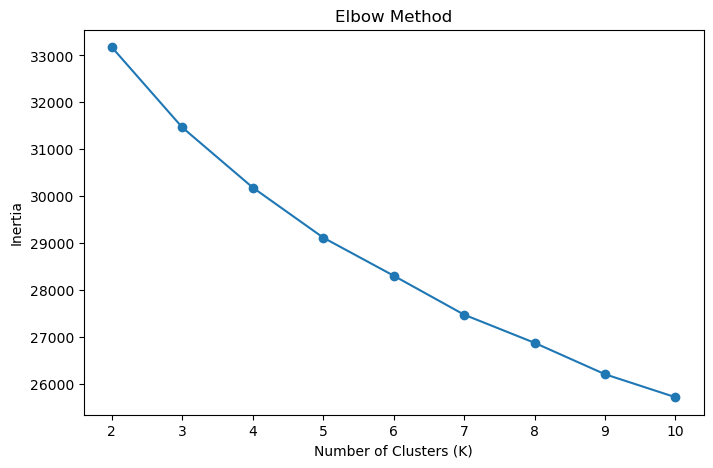

In [18]:
# Elbow Method
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertias = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), inertias, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

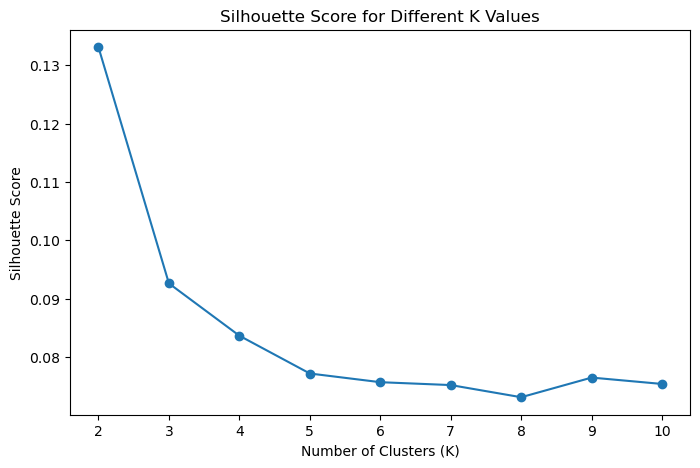

In [19]:
# Silhouette Score
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(X)
    
    score = silhouette_score(X, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), silhouette_scores, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Different K Values")
plt.show()

In [20]:
# Print the scores
for k, score in zip(range(2, 11), silhouette_scores):
    print("K =", k, "Silhouette Score =", round(score, 4))

K = 2 Silhouette Score = 0.1331
K = 3 Silhouette Score = 0.0926
K = 4 Silhouette Score = 0.0837
K = 5 Silhouette Score = 0.0772
K = 6 Silhouette Score = 0.0757
K = 7 Silhouette Score = 0.0752
K = 8 Silhouette Score = 0.0731
K = 9 Silhouette Score = 0.0765
K = 10 Silhouette Score = 0.0754


In [21]:
# the final K-Means model.
best_k = range(2, 11)[silhouette_scores.index(max(silhouette_scores))]

print("Best K:", best_k)
print("Best Silhouette Score:", max(silhouette_scores))

Best K: 2
Best Silhouette Score: 0.13306033696766253


In [22]:
# Train final K-Means
final_kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

df["Cluster"] = final_kmeans.fit_predict(X)

print("K-Means clustering completed!")
print(df[["Customer ID", "Cluster"]].head())

K-Means clustering completed!
   Customer ID  Cluster
0            1        0
1            2        0
2            3        0
3            4        0
4            5        0


In [24]:
# Check cluster sizes
cluster_counts = df["Cluster"].value_counts().sort_index()

print("Customers in each cluster:")
print(cluster_counts)

Customers in each cluster:
Cluster
0    1677
1    2223
Name: count, dtype: int64


In [25]:
# Save the clustering result
df.to_csv("customer_segments.csv", index=False)

print("customer_segments.csv saved successfully!")

customer_segments.csv saved successfully!


In [26]:
# Profile the clusters
segment_profile = df.groupby("Cluster").agg(
    Customers=("Customer ID", "count"),
    Average_Age=("Age", "mean"),
    Average_Spending=("Purchase Amount (USD)", "mean"),
    Average_Rating=("Review Rating", "mean"),
    Average_Previous_Purchases=("Previous Purchases", "mean")
).round(2)

print(segment_profile)

         Customers  Average_Age  Average_Spending  Average_Rating  \
Cluster                                                             
0             1677        44.14             59.28            3.74   
1             2223        44.01             60.13            3.76   

         Average_Previous_Purchases  
Cluster                              
0                             25.74  
1                             25.06  


In [28]:
# Add total spending
segment_revenue = df.groupby("Cluster")["Purchase Amount (USD)"].sum()

segment_profile["Total_Spending"] = segment_revenue.round(2)

total_spending = df["Purchase Amount (USD)"].sum()

segment_profile["Revenue_Contribution_%"] = (
    segment_profile["Total_Spending"] / total_spending * 100
).round(2)

print(segment_profile)

         Customers  Average_Age  Average_Spending  Average_Rating  \
Cluster                                                             
0             1677        44.14             59.28            3.74   
1             2223        44.01             60.13            3.76   

         Average_Previous_Purchases  Total_Spending  Revenue_Contribution_%  
Cluster                                                                      
0                             25.74           99411                   42.65  
1                             25.06          133670                   57.35  


In [30]:
# See the cluster characteristics
print("Customer Segment Profile")
print(segment_profile)

Customer Segment Profile
         Customers  Average_Age  Average_Spending  Average_Rating  \
Cluster                                                             
0             1677        44.14             59.28            3.74   
1             2223        44.01             60.13            3.76   

         Average_Previous_Purchases  Total_Spending  Revenue_Contribution_%  
Cluster                                                                      
0                             25.74           99411                   42.65  
1                             25.06          133670                   57.35  


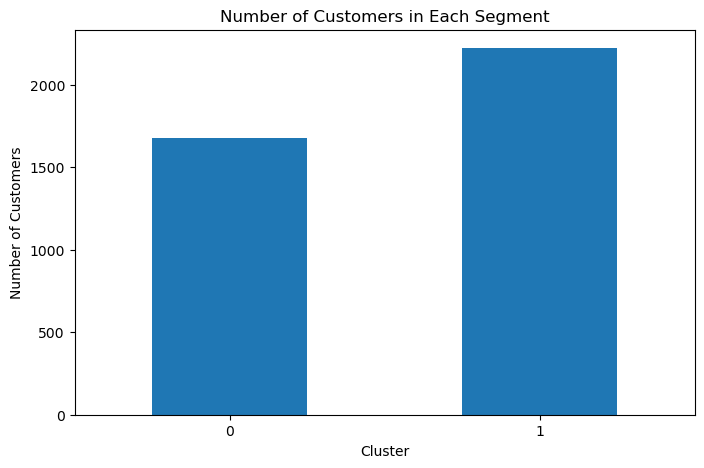

In [31]:
# Visualize segment sizes
import matplotlib.pyplot as plt

segment_profile["Customers"].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Number of Customers in Each Segment")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()

In [35]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# Target
y = df["Review Rating"]

# Features
reg_features = [
    "Age",
    "Purchase Amount (USD)",
    "Previous Purchases"
]

X_reg = df[reg_features]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_reg,
    y,
    test_size=0.2,
    random_state=42
)

# -------------------------
# Linear Regression
# -------------------------
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

y_pred_linear = linear_model.predict(X_test)

mae_linear = mean_absolute_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_linear))
r2_linear = r2_score(y_test, y_pred_linear)

# -------------------------
# Ridge Regression
# -------------------------
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)

y_pred_ridge = ridge_model.predict(X_test)

mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2_ridge = r2_score(y_test, y_pred_ridge)

# -------------------------
# Results
# -------------------------
regression_comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge Regression"],
    "MAE": [mae_linear, mae_ridge],
    "RMSE": [rmse_linear, rmse_ridge],
    "R2": [r2_linear, r2_ridge]
})

print(regression_comparison)


               Model       MAE      RMSE        R2
0  Linear Regression  0.647003  0.738704 -0.000775
1   Ridge Regression  0.647003  0.738704 -0.000775


In [36]:
# Ridge Regression
ridge_model = Ridge(alpha=1.0)

ridge_model.fit(X_train, y_train)

y_pred_ridge = ridge_model.predict(X_test)

mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2_ridge = r2_score(y_test, y_pred_ridge)

print("Ridge Regression")
print("MAE :", round(mae_ridge, 4))
print("RMSE:", round(rmse_ridge, 4))
print("R²  :", round(r2_ridge, 4))

Ridge Regression
MAE : 0.647
RMSE: 0.7387
R²  : -0.0008


In [38]:
# Compare the models
regression_comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge Regression"],
    "MAE": [mae_linear, mae_ridge],
    "RMSE": [rmse_linear, rmse_ridge],
    "R2": [r2_linear, r2_ridge]
})

print(regression_comparison)

               Model       MAE      RMSE        R2
0  Linear Regression  0.647003  0.738704 -0.000775
1   Ridge Regression  0.647003  0.738704 -0.000775


In [39]:
# Classification using Logistic Regression.
# Convert Subscription Status into 0/1
y_class = df["Subscription Status"].map({
    "Yes": 1,
    "No": 0
})

print(y_class.value_counts())

Subscription Status
0    2847
1    1053
Name: count, dtype: int64


In [41]:
# Select features
class_features = [
    "Age",
    "Purchase Amount (USD)",
    "Previous Purchases",
    "Review Rating"
]

X_class = df[class_features]

print(X_class.head())

   Age  Purchase Amount (USD)  Previous Purchases  Review Rating
0   55                     53                  14            3.1
1   19                     64                   2            3.1
2   50                     73                  23            3.1
3   21                     90                  49            3.5
4   45                     49                  31            2.7


In [42]:
# Train/test split
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_class,
    y_class,
    test_size=0.2,
    random_state=42,
    stratify=y_class
)

print("Training:", X_train_c.shape)
print("Testing:", X_test_c.shape)

Training: (3120, 4)
Testing: (780, 4)


In [43]:
# Train Logistic Regression
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

scaler = StandardScaler()

X_train_c_scaled = scaler.fit_transform(X_train_c)
X_test_c_scaled = scaler.transform(X_test_c)

log_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

log_model.fit(X_train_c_scaled, y_train_c)

y_pred_class = log_model.predict(X_test_c_scaled)
y_prob_class = log_model.predict_proba(X_test_c_scaled)[:, 1]

print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


In [44]:
# Evaluate
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

accuracy = accuracy_score(y_test_c, y_pred_class)
precision = precision_score(y_test_c, y_pred_class)
recall = recall_score(y_test_c, y_pred_class)
f1 = f1_score(y_test_c, y_pred_class)
roc_auc = roc_auc_score(y_test_c, y_prob_class)

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))
print("ROC-AUC  :", round(roc_auc, 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_c, y_pred_class))

Accuracy : 0.7295
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0
ROC-AUC  : 0.4715

Confusion Matrix:
[[569   0]
 [211   0]]


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [45]:
# Step 12 — Improve Logistic Regression
class_features = [
    "Age",
    "Purchase Amount (USD)",
    "Review Rating",
    "Previous Purchases",
    "Discount Applied",
    "Promo Code Used",
    "Gender",
    "Category",
    "Payment Method",
    "Shipping Type",
    "Frequency of Purchases"
]

X_class = df[class_features]

print(X_class.head())

   Age  Purchase Amount (USD)  Review Rating  Previous Purchases  \
0   55                     53            3.1                  14   
1   19                     64            3.1                   2   
2   50                     73            3.1                  23   
3   21                     90            3.5                  49   
4   45                     49            2.7                  31   

  Discount Applied Promo Code Used Gender  Category Payment Method  \
0              Yes             Yes   Male  Clothing    Credit Card   
1              Yes             Yes   Male  Clothing  Bank Transfer   
2              Yes             Yes   Male  Clothing           Cash   
3              Yes             Yes   Male  Footwear         PayPal   
4              Yes             Yes   Male  Clothing           Cash   

   Shipping Type Frequency of Purchases  
0        Express            Fortnightly  
1        Express            Fortnightly  
2  Free Shipping                 Weekly  
3 

In [46]:
# Separate numerical and categorical features
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numeric_class = [
    "Age",
    "Purchase Amount (USD)",
    "Review Rating",
    "Previous Purchases"
]

categorical_class = [
    "Discount Applied",
    "Promo Code Used",
    "Gender",
    "Category",
    "Payment Method",
    "Shipping Type",
    "Frequency of Purchases"
]

preprocessor_class = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_class),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_class)
    ]
)

In [47]:
# Split the data
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_class,
    y_class,
    test_size=0.2,
    random_state=42,
    stratify=y_class
)

In [48]:
# Transform the data
X_train_c = preprocessor_class.fit_transform(X_train_c)
X_test_c = preprocessor_class.transform(X_test_c)

In [50]:
# Train Logistic Regression
log_model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=42
)

log_model.fit(X_train_c, y_train_c)

y_pred_class = log_model.predict(X_test_c)
y_prob_class = log_model.predict_proba(X_test_c)[:, 1]

print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


In [51]:
# Evaluate again
accuracy = accuracy_score(y_test_c, y_pred_class)
precision = precision_score(
    y_test_c,
    y_pred_class,
    zero_division=0
)
recall = recall_score(
    y_test_c,
    y_pred_class,
    zero_division=0
)
f1 = f1_score(
    y_test_c,
    y_pred_class,
    zero_division=0
)
roc_auc = roc_auc_score(y_test_c, y_prob_class)

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))
print("ROC-AUC  :", round(roc_auc, 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_c, y_pred_class))

Accuracy : 0.8641
Precision: 0.6656
Recall   : 1.0
F1 Score : 0.7992
ROC-AUC  : 0.9162

Confusion Matrix:
[[463 106]
 [  0 211]]


In [53]:
# Hyperparameter Tuning with GridSearchCV
# Create GridSearchCV
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

param_grid = {
    "C": [0.01, 0.1, 1, 10, 100]
}

grid_search = GridSearchCV(
    LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ),
    param_grid=param_grid,
    cv=5,
    scoring="f1"
)

grid_search.fit(X_train_c, y_train_c)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation F1 Score:")
print(grid_search.best_score_)

Best Parameters:
{'C': 0.01}

Best Cross-Validation F1 Score:
0.764808705749503


In [54]:
# Get the tuned model
best_model = grid_search.best_estimator_

y_pred_tuned = best_model.predict(X_test_c)
y_prob_tuned = best_model.predict_proba(X_test_c)[:, 1]

print("Tuned model created successfully!")

Tuned model created successfully!


In [55]:
# Evaluate tuned model
accuracy_tuned = accuracy_score(y_test_c, y_pred_tuned)

precision_tuned = precision_score(
    y_test_c,
    y_pred_tuned,
    zero_division=0
)

recall_tuned = recall_score(
    y_test_c,
    y_pred_tuned,
    zero_division=0
)

f1_tuned = f1_score(
    y_test_c,
    y_pred_tuned,
    zero_division=0
)

roc_auc_tuned = roc_auc_score(
    y_test_c,
    y_prob_tuned
)

print("Tuned Logistic Regression")
print("-------------------------")
print("Accuracy :", round(accuracy_tuned, 4))
print("Precision:", round(precision_tuned, 4))
print("Recall   :", round(recall_tuned, 4))
print("F1 Score :", round(f1_tuned, 4))
print("ROC-AUC  :", round(roc_auc_tuned, 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_c, y_pred_tuned))


Tuned Logistic Regression
-------------------------
Accuracy : 0.8641
Precision: 0.6656
Recall   : 1.0
F1 Score : 0.7992
ROC-AUC  : 0.9117

Confusion Matrix:
[[463 106]
 [  0 211]]


In [56]:
# Compare before vs after tuning
comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    "Before Tuning": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ],
    "After Tuning": [
        accuracy_tuned,
        precision_tuned,
        recall_tuned,
        f1_tuned,
        roc_auc_tuned
    ]
})

print(comparison.round(4))

      Metric  Before Tuning  After Tuning
0   Accuracy         0.8641        0.8641
1  Precision         0.6656        0.6656
2     Recall         1.0000        1.0000
3   F1 Score         0.7992        0.7992
4    ROC-AUC         0.9162        0.9117


In [57]:
# Final Model Comparison
model_comparison = pd.DataFrame({
    "Model": [
        "K-Means",
        "Linear Regression",
        "Ridge Regression",
        "Logistic Regression"
    ],
    
    "Objective": [
        "Customer Segmentation",
        "Predict Customer Rating",
        "Predict Customer Rating",
        "Predict Purchase Likelihood"
    ],
    
    "Metric": [
        "Silhouette Score",
        "RMSE / R2",
        "RMSE / R2",
        "Accuracy / Precision / Recall / F1 / ROC-AUC"
    ],
    
    "Result": [
        max(silhouette_scores),
        f"RMSE={rmse_linear:.4f}, R2={r2_linear:.4f}",
        f"RMSE={rmse_ridge:.4f}, R2={r2_ridge:.4f}",
        f"F1={f1_tuned:.4f}, ROC-AUC={roc_auc_tuned:.4f}"
    ],
    
    "Business Use": [
        "Create customer segments",
        "Predict customer ratings",
        "Predict customer ratings",
        "Identify likely customers"
    ]
})

print(model_comparison)

                 Model                    Objective  \
0              K-Means        Customer Segmentation   
1    Linear Regression      Predict Customer Rating   
2     Ridge Regression      Predict Customer Rating   
3  Logistic Regression  Predict Purchase Likelihood   

                                         Metric                     Result  \
0                              Silhouette Score                    0.13306   
1                                     RMSE / R2    RMSE=0.7387, R2=-0.0008   
2                                     RMSE / R2    RMSE=0.7387, R2=-0.0008   
3  Accuracy / Precision / Recall / F1 / ROC-AUC  F1=0.7992, ROC-AUC=0.9117   

                Business Use  
0   Create customer segments  
1   Predict customer ratings  
2   Predict customer ratings  
3  Identify likely customers  


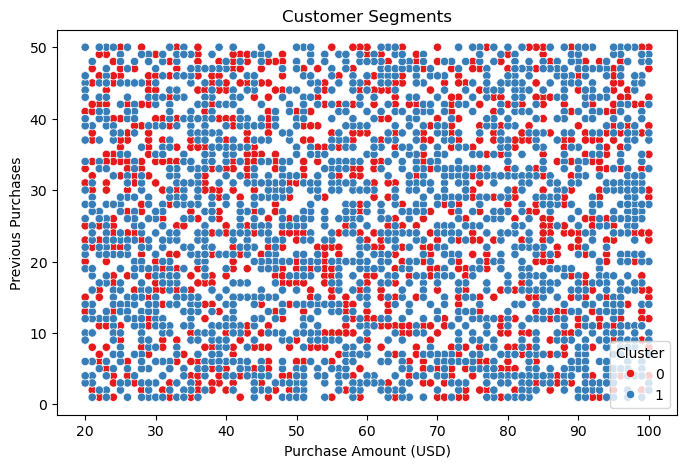

In [58]:
# Visualize the Customer Segments
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Purchase Amount (USD)",
    y="Previous Purchases",
    hue="Cluster",
    palette="Set1"
)

plt.title("Customer Segments")
plt.xlabel("Purchase Amount (USD)")
plt.ylabel("Previous Purchases")
plt.show()

In [59]:
# Create Business Recommendations
print(segment_profile)

         Customers  Average_Age  Average_Spending  Average_Rating  \
Cluster                                                             
0             1677        44.14             59.28            3.74   
1             2223        44.01             60.13            3.76   

         Average_Previous_Purchases  Total_Spending  Revenue_Contribution_%  
Cluster                                                                      
0                             25.74           99411                   42.65  
1                             25.06          133670                   57.35  


In [60]:
for cluster in segment_profile.index:
    print("\nCluster", cluster)
    
    spending = segment_profile.loc[cluster, "Average_Spending"]
    rating = segment_profile.loc[cluster, "Average_Rating"]
    previous = segment_profile.loc[cluster, "Average_Previous_Purchases"]
    
    if spending > df["Purchase Amount (USD)"].mean():
        print("Segment: High Value Customers")
        print("Recommendation: Offer loyalty rewards and premium products.")
        
    elif previous > df["Previous Purchases"].mean():
        print("Segment: Frequent Customers")
        print("Recommendation: Provide personalized offers and repeat-purchase discounts.")
        
    else:
        print("Segment: Low Engagement Customers")
        print("Recommendation: Use targeted promotions and re-engagement campaigns.")


Cluster 0
Segment: Frequent Customers
Recommendation: Provide personalized offers and repeat-purchase discounts.

Cluster 1
Segment: High Value Customers
Recommendation: Offer loyalty rewards and premium products.


In [61]:
# Save the Final Results
segment_profile.to_csv(
    "customer_segment_report.csv"
)

print("Customer segment report saved successfully!")

Customer segment report saved successfully!


In [62]:
segment_profile.to_csv(
    "customer_segment_report.csv"
)

print("Customer segment report saved successfully!")

Customer segment report saved successfully!


In [63]:
model_comparison.to_csv(
    "model_comparison.csv",
    index=False
)

print("model_comparison.csv created successfully!")

model_comparison.csv created successfully!


In [64]:
print(segment_profile)

         Customers  Average_Age  Average_Spending  Average_Rating  \
Cluster                                                             
0             1677        44.14             59.28            3.74   
1             2223        44.01             60.13            3.76   

         Average_Previous_Purchases  Total_Spending  Revenue_Contribution_%  
Cluster                                                                      
0                             25.74           99411                   42.65  
1                             25.06          133670                   57.35  
